### Imports 

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [11]:
import sys
print(sys.executable)

/home/user_stel/miniconda3/bin/python


### Loading the Data

In [ ]:
path_to_dev = "../data/assignment1_dev_set.csv"
path_to_val = "../data/assignment1_val_set.csv"

# Function that retrieves data from a provided path
# and reads the data as a pandas dataframe
def load_data(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"The file at {path} was not found.")
    if 'dev' in path:
        print('Data for development:')
    elif 'val' in path:
        print('Data for evaluation:')
    else:
        raise ValueError("The path provided does not contain data for development nor for evaluation.")
    data = pd.read_csv(path)
    return data

dev_set_df=load_data(path_to_dev)
print(dev_set_df.head())
print(dev_set_df.info())
print(list(dev_set_df.columns))
val_set_df=load_data(path_to_val)
print(val_set_df.head())




Data for development:
   Unnamed: 0   Project ID Experiment type     Sex  Host age    BMI  \
0           0   PRJEB11419    Metagenomics    Male      53.0  19.01   
1           1  PRJNA388263    Metagenomics  Female      21.0  23.50   
2           2  PRJNA388263    Metagenomics    Male      52.0  25.80   
3           3   PRJEB11419    Metagenomics  Female      40.0  23.49   
4           4   PRJEB11419    Metagenomics  Female      30.0  22.60   

  Disease MESH ID  Acholeplasma axanthum  Acidaminococcus fermentans  \
0         D006262               0.000000                    0.000000   
1         D006262               0.001028                    0.000000   
2         D006262               0.001406                    0.000000   
3         D006262               0.000000                    0.008825   
4         D006262               0.002878                    0.037419   

   Acidaminococcus intestini  ...  Clostridium sphenoides  \
0                   0.000000  ...                0.005891

### Data Preprocessing

In [ ]:
# Removal of unnecessary columns 
# Unnamed:0, Project ID, Experiment type, Sex, Host age
unnecessary_columns=['Unnamed: 0', 'Project ID', 'Experiment type', 'Disease MESH ID']

# Handling missing values (if any)




In [ ]:
# Removal of unnecessary columns 
# Unnamed:0, Project ID, Experiment type, Sex, Host age
unnecessary_columns=['Unnamed: 0', 'Project ID', 'Experiment type', 'Sex', 'Disease MESH ID']

dev_set_reduced_df=dev_set_df.drop(columns=unnecessary_columns)
val_set_reduced_df=val_set_df.drop(columns=unnecessary_columns)

print("Development Data after Preprocessing:")
print(dev_set_reduced_df.head())

# Check for missing values 
dev_set_missing_df=dev_set_reduced_df.isnull().sum()
print("Missing Values:")
print(dev_set_missing_df)

# Save Pandas Dataframes as CSV files
val_set_reduced_df.to_csv('evaluation_final_data.csv')

Development Data after Preprocessing:
   Host age    BMI  Acholeplasma axanthum  Acidaminococcus fermentans  \
0      53.0  19.01               0.000000                    0.000000   
1      21.0  23.50               0.001028                    0.000000   
2      52.0  25.80               0.001406                    0.000000   
3      40.0  23.49               0.000000                    0.008825   
4      30.0  22.60               0.002878                    0.037419   

   Acidaminococcus intestini  Actinomyces lingnae  Akkermansia muciniphila  \
0                   0.000000             0.000000                 0.017674   
1                   0.000000             0.000000                13.015800   
2                   0.000000             0.001406                 0.002812   
3                   0.273562             0.000000                 0.044123   
4                   7.359970             0.000000                 0.872143   

   Alistipes finegoldii  Alistipes indistinctus  Alist

### Feature Selection

Highly correlated pairs:
Streptococcus mitis              Streptococcus oralis                       0.984661
Hungatella hathewayi             Lachnospiraceae bacterium 3_1_57FAA_CT1    0.980509
Bacteroides graminisolvens       Prevotella ruminicola                      0.910267
Prevotella bivia                 Prevotella shahii                          0.906563
Porphyromonas catoniae           Streptococcus mitis                        0.875085
Bacteroides intestinalis         Ruminococcaceae bacterium D16              0.864316
Bacillus megaterium              Clostridium amylolyticum                   0.860058
Anaerostipes butyraticus         Anaerostipes caccae                        0.851647
Porphyromonas catoniae           Streptococcus oralis                       0.832220
Actinomyces lingnae              Fusobacterium nucleatum                    0.805016
Blautia glucerasea               Ruminococcus gnavus                        0.755592
Clostridium asparagiforme        Clostri

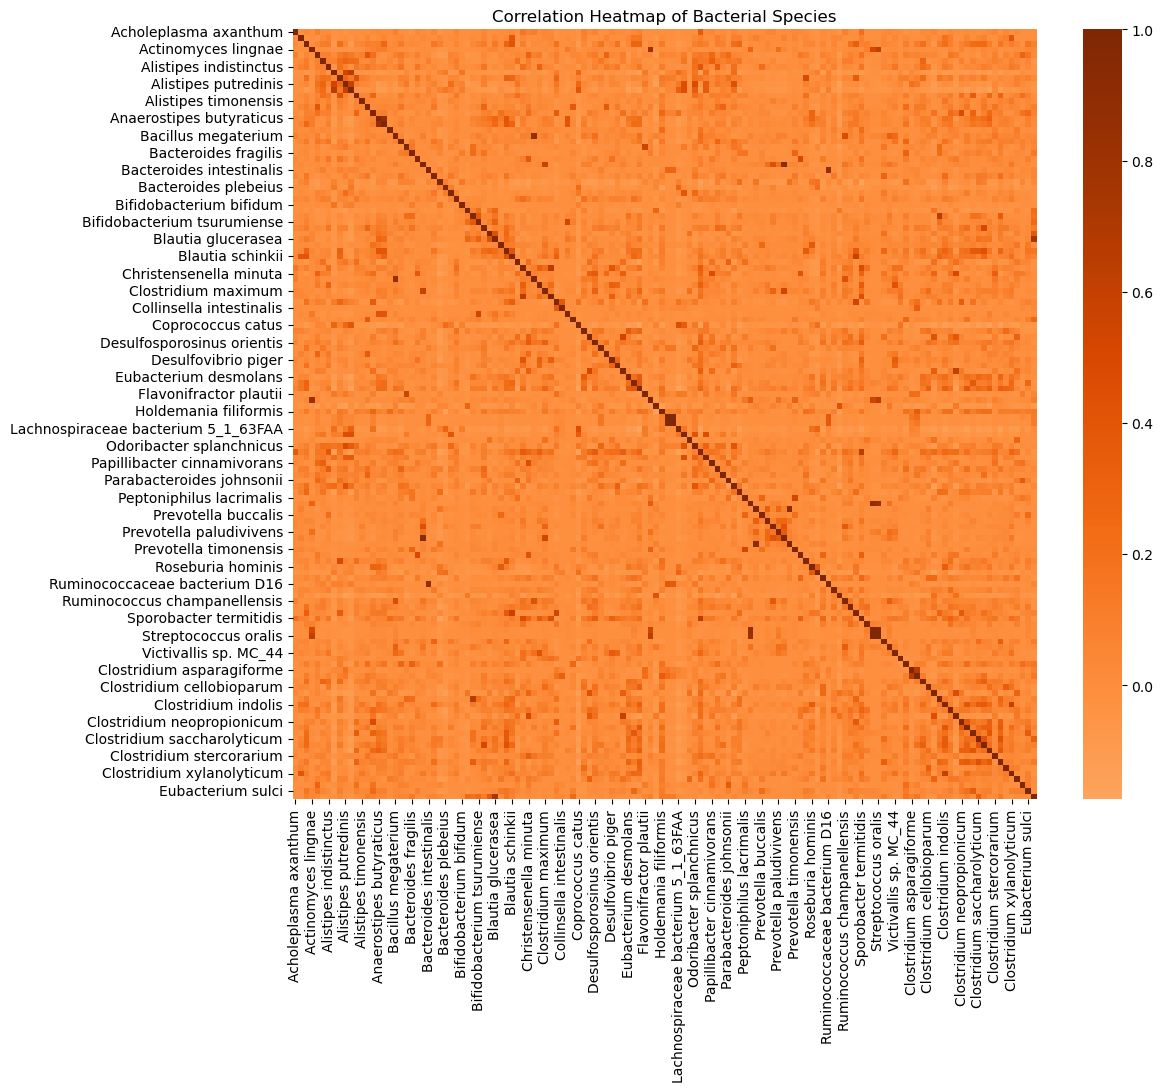

In [7]:
# Pearson's Correlation Coefficient for Bacteria species 
# Check for high correlation between bacteria species in order to exclude some of the species and reduce dimensionality 
bacteria_species=dev_set_reduced_df.columns.drop(['BMI', 'Host age'])
correlation_matrix=dev_set_reduced_df[bacteria_species].corr(method='pearson')

threshold = 0.5
high_corr_pairs = (
    correlation_matrix.abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs > threshold]

print("Highly correlated pairs:")
print(high_corr_pairs)

# Species to remove (second species in each pair)
species_to_remove = set()

for pair in high_corr_pairs.index:
    species_to_remove.add(pair[1])

print("Species to remove:", species_to_remove)

# Drop highly correlated species
dev_set_cleaned_df = dev_set_reduced_df.drop(columns=species_to_remove)
print(f"Reduced from {len(dev_set_reduced_df.columns)} to {len(dev_set_cleaned_df.columns)} columns.")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='Oranges', center=0)
plt.title('Correlation Heatmap of Bacterial Species')
plt.show()

dev_set_cleaned_df.to_csv('development_final_data.csv')

### Principal Component Analysis

Explained variance ratios: [6.27950005e-01 1.07685957e-01 4.97835606e-02 4.10888056e-02
 3.01788739e-02 1.66250835e-02 1.47630936e-02 1.40515649e-02
 1.10819224e-02 8.49835594e-03 8.23822948e-03 7.61451693e-03
 6.27316684e-03 5.82693552e-03 5.34881256e-03 4.78991898e-03
 4.22398767e-03 3.45275834e-03 2.90739244e-03 2.44345041e-03
 2.23995255e-03 1.75985861e-03 1.57330776e-03 1.50889633e-03
 1.42467409e-03 1.22595212e-03 1.21369180e-03 1.09083421e-03
 1.03960032e-03 9.90870304e-04 9.36835933e-04 8.72243122e-04
 7.91896618e-04 7.31326201e-04 7.00671220e-04 6.12267026e-04
 5.62059384e-04 5.36495117e-04 5.23522411e-04 4.82134764e-04
 4.76807766e-04 4.30855579e-04 4.14132564e-04 3.57944849e-04
 3.41873994e-04 3.04505543e-04 2.95830455e-04 2.73568090e-04
 2.53090590e-04 2.44785109e-04 2.31245893e-04 2.18852083e-04
 1.90406143e-04 1.87614026e-04 1.59341210e-04 1.50933029e-04
 1.38290516e-04 1.35895099e-04 1.29852962e-04 1.08349773e-04
 1.01360470e-04 9.21741782e-05 8.31554912e-05 7.69996568e-

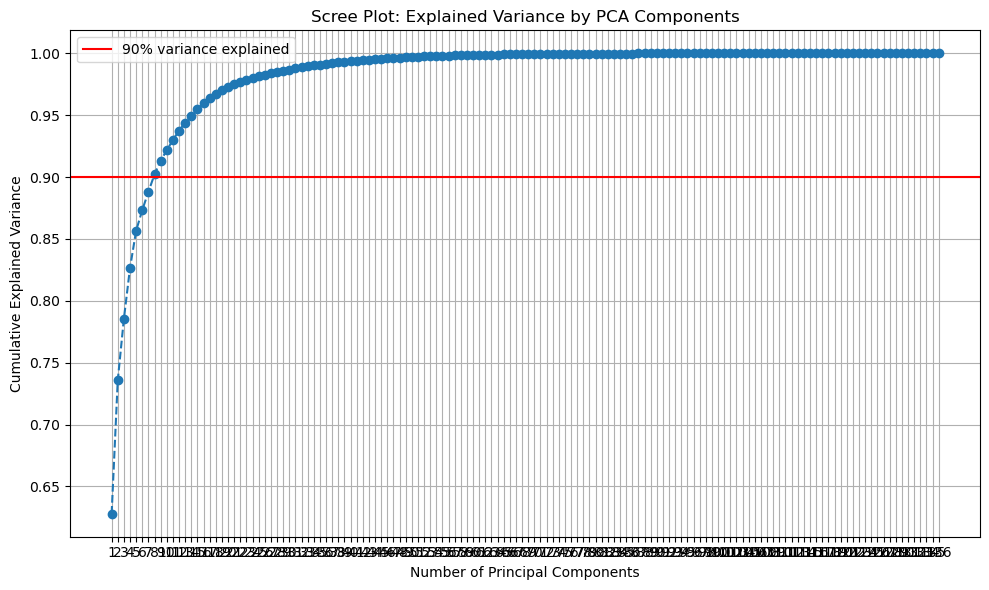

In [5]:
pca = PCA(n_components=min(dev_set_reduced_df.shape))
dev_set_reduced_pca = pca.fit_transform(dev_set_reduced_df)
explained_variances = pca.explained_variance_ratio_

# PCA explained variance ratio
print("Explained variance ratios:", explained_variances)

plt.figure(figsize=(10, 6))

# Cumulative explained variance plot
plt.plot(range(1, len(explained_variances) + 1), 
         explained_variances.cumsum(), 
         marker='o', linestyle='--')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Explained Variance by PCA Components')
plt.grid(True)
plt.xticks(range(1, len(explained_variances) + 1))
plt.axhline(y=0.90, color='r', linestyle='-', label='90% variance explained')
plt.legend()
plt.tight_layout()
plt.show()


### Data Visualization

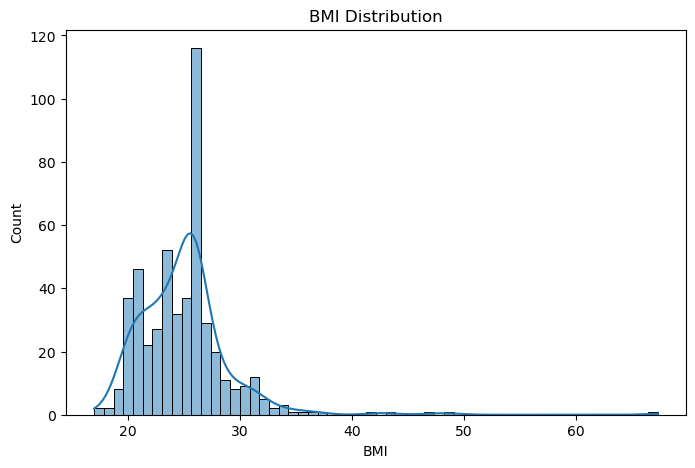

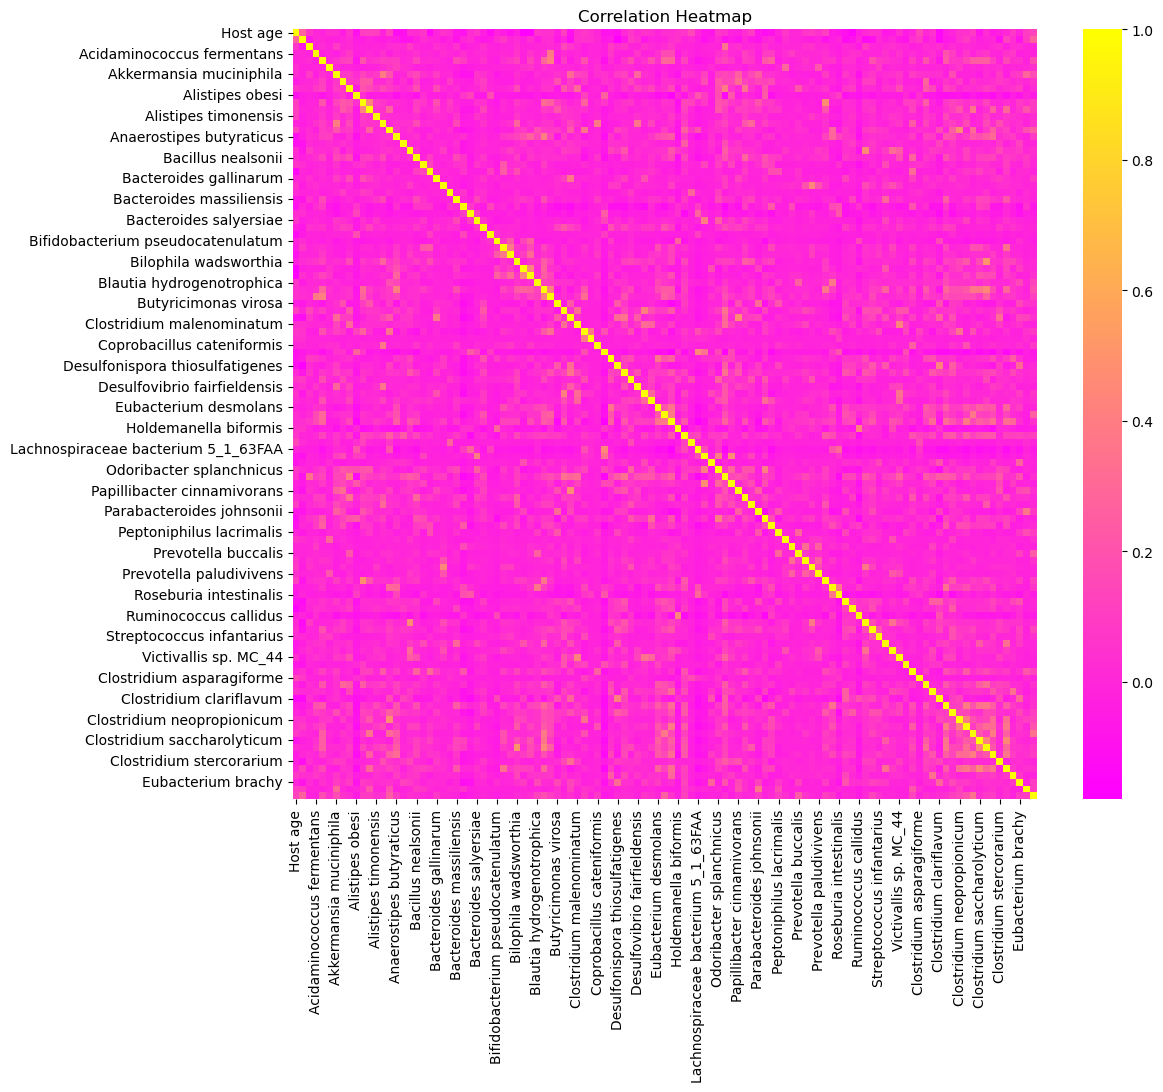

/tmp/ipykernel_40515/2762597477.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_abundance.index, y=mean_abundance.values, palette="viridis")


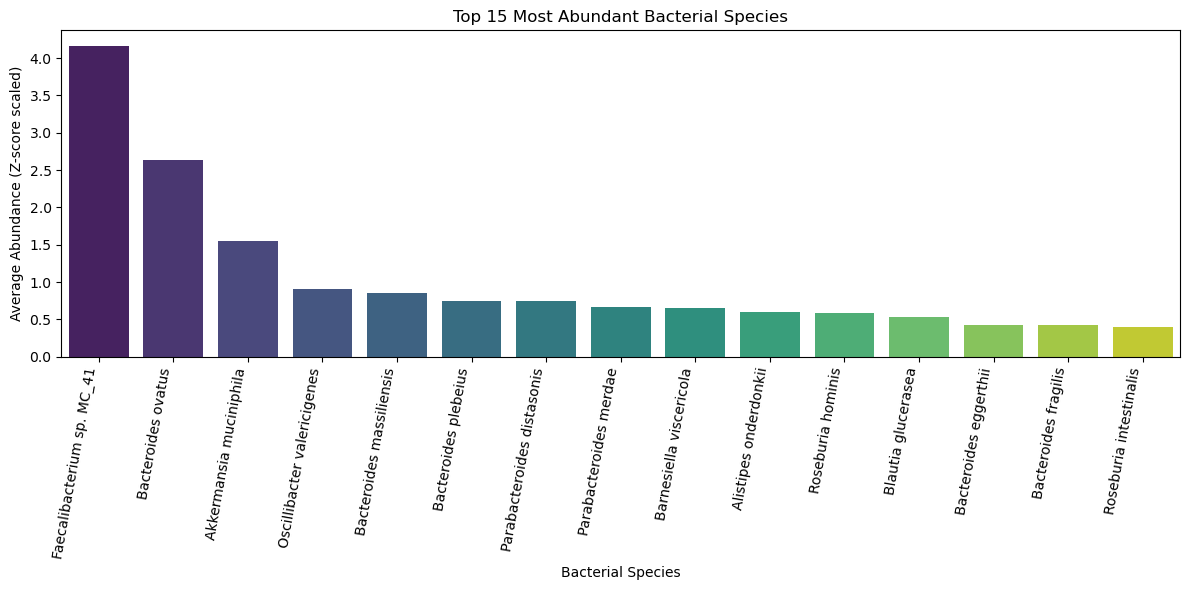

In [6]:
# Example: BMI distribution plot
plt.figure(figsize=(8, 5))
sns.histplot(dev_set_cleaned_df['BMI'], kde=True)
plt.title("BMI Distribution")
plt.show()

# Correlation heatmap (clearly visualizes relationships)
plt.figure(figsize=(12, 10))
sns.heatmap(dev_set_cleaned_df.corr(), cmap='spring')
plt.title("Correlation Heatmap")
plt.show()

# Calculate mean abundance for each bacterial species across samples
bacteria_species_cleaned=dev_set_cleaned_df.columns.drop(['BMI', 'Host age'])
mean_abundance = dev_set_cleaned_df[bacteria_species_cleaned].mean().sort_values(ascending=False).head(15)

# Plotting the top 15 most abundant bacteria species
plt.figure(figsize=(12, 6))
sns.barplot(x=mean_abundance.index, y=mean_abundance.values, palette="viridis")

plt.title('Top 15 Most Abundant Bacterial Species')
plt.ylabel('Average Abundance (Z-score scaled)')
plt.xlabel('Bacterial Species')
plt.xticks(rotation=80, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Generate baseline model with default parameters and no feature selection

df_features = dev_set_reduced_df.drop(columns=['BMI', 'Host age'], errors='ignore')
df_target = dev_set_reduced_df['BMI']

x_train, x_test, y_train, y_test = train_test_split(
    df_features, df_target, test_size=0.2, random_state=42
)


models={
    'enet':ElasticNet(),
    'svr':SVR(),
    'breg':BayesianRidge()
}

def train_model(model, x_train, x_test, y_train, y_test):
    results={}

    for model, model_instance in models.items():
        model_instance.fit(x_train, y_train)
        y_pred=model_instance.predict(x_test)
        mse=mean_squared_error(y_test, y_pred)
        results[model]=mse
        print(f"{model} MSE: {mse:.4f}")
    return results

model_results = train_model(models, x_train, x_test, y_train, y_test)


enet MSE: 11.1095
svr MSE: 9.9538
breg MSE: 11.5263
